# GR_AP1 analysis - Part 2

Step 1: Run the test-variants.py script with the A549 Dex and DMSO model on Chris Vockley's sequences separately and plot the distance dependent activation

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_table('/hpc/home/rv103/igvf/revathy/GR-AP1/logFC/DMSO_27_DEX_7_MSELoss_original-seq-fc3.txt',header = None)
df.columns = ['location', 'DMSO.refScore', 'Dex.refScore','sequence'] 
df

,location,DMSO.refScore,Dex.refScore,sequence
0,seq1,0.773162,0.940196,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
1,seq2,0.886822,0.892706,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
2,seq3,0.851194,0.829670,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
3,seq4,0.722088,0.797816,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
4,seq5,0.666548,0.860601,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
5,seq6,0.663641,0.818965,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
6,seq7,0.651367,0.846697,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
7,seq8,0.642997,0.668046,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
8,seq9,0.694345,0.698867,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...
9,seq10,0.679947,0.703534,ACCTGAGCTCGCTAGCCTCGAGGATCTTGGCAGTACTCCCAGTTCT...


In [13]:
	
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.markersize'] = 20
sns.set_context('talk')
%matplotlib inline

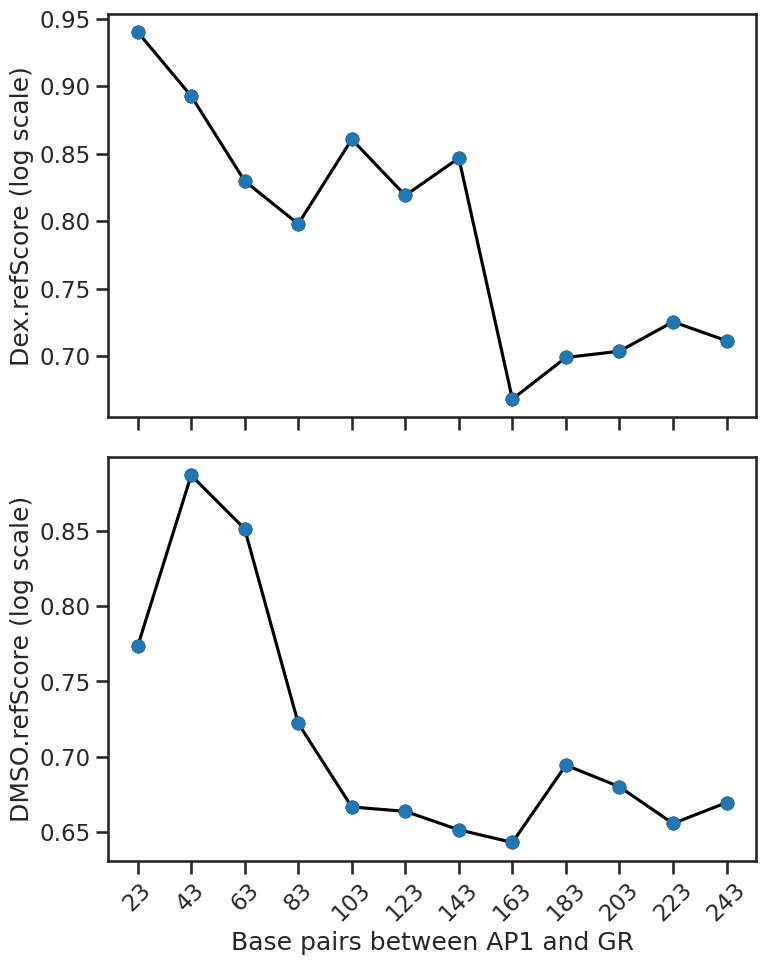

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_table(
    '/hpc/home/rv103/igvf/revathy/GR-AP1/logFC/DMSO_27_DEX_7_MSELoss_original-seq-fc3.txt',
    header=None
)
df.columns = ['location', 'DMSO.refScore', 'Dex.refScore', 'sequence']

# Distance vector
df['dist'] = np.tile(np.arange(23, 244, 20), 1)

# Aggregate statistics
agg_df = (
    df.groupby('dist')
      .agg(
          mean_dex=('Dex.refScore', 'mean'),
          sd_dex=('Dex.refScore', 'std'),
          mean_dmso=('DMSO.refScore', 'mean'),
          sd_dmso=('DMSO.refScore', 'std')
      )
      .reset_index()
)

# Create subplots
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8, 10),sharex=True)

axes[0].plot(agg_df['dist'], agg_df['mean_dex'], marker='o', color='black')
axes[0].errorbar(agg_df['dist'], agg_df['mean_dex'], yerr=agg_df['sd_dex'], fmt='o', capsize=5)
axes[0].set_ylabel("Dex.refScore (log scale)")
# axes[0].set_xlabel("Base pairs between AP1 and GR")

axes[1].plot(agg_df['dist'], agg_df['mean_dmso'],marker='o', color='black')
axes[1].errorbar(agg_df['dist'], agg_df['mean_dmso'], yerr=agg_df['sd_dex'], fmt='o', capsize=5)
axes[1].set_ylabel("DMSO.refScore (log scale)")
axes[1].set_xlabel("Base pairs between AP1 and GR")

# X ticks
axes[1].set_xticks(np.arange(23, 244, 20))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
